# Lane Detection Tuning

Interactive notebook to tune `lane_pid.py` on saved BeamNG screenshots.
Run cell-1 to reload `lane_pid` after any edit, then re-run cell-2 to see the result instantly.

In [1]:
import importlib
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import lane_pid as _lane_pid_module
importlib.reload(_lane_pid_module)
from lane_pid import detect_lane_lines, lane_center_error

SCREENSHOTS_DIR = Path("screenshots")
images = sorted(SCREENSHOTS_DIR.glob("*.png"))
print(f"Found {len(images)} screenshots:")
for p in images:
    print(f"  {p.name}")

Found 7 screenshots:
  frame_20260627_122320_00046.png
  frame_20260627_122331_00100.png
  frame_20260627_122333_00109.png
  frame_20260627_122339_00139.png
  frame_20260627_122359_00233.png
  frame_20260627_122403_00253.png
  frame_20260627_124412_00369.png


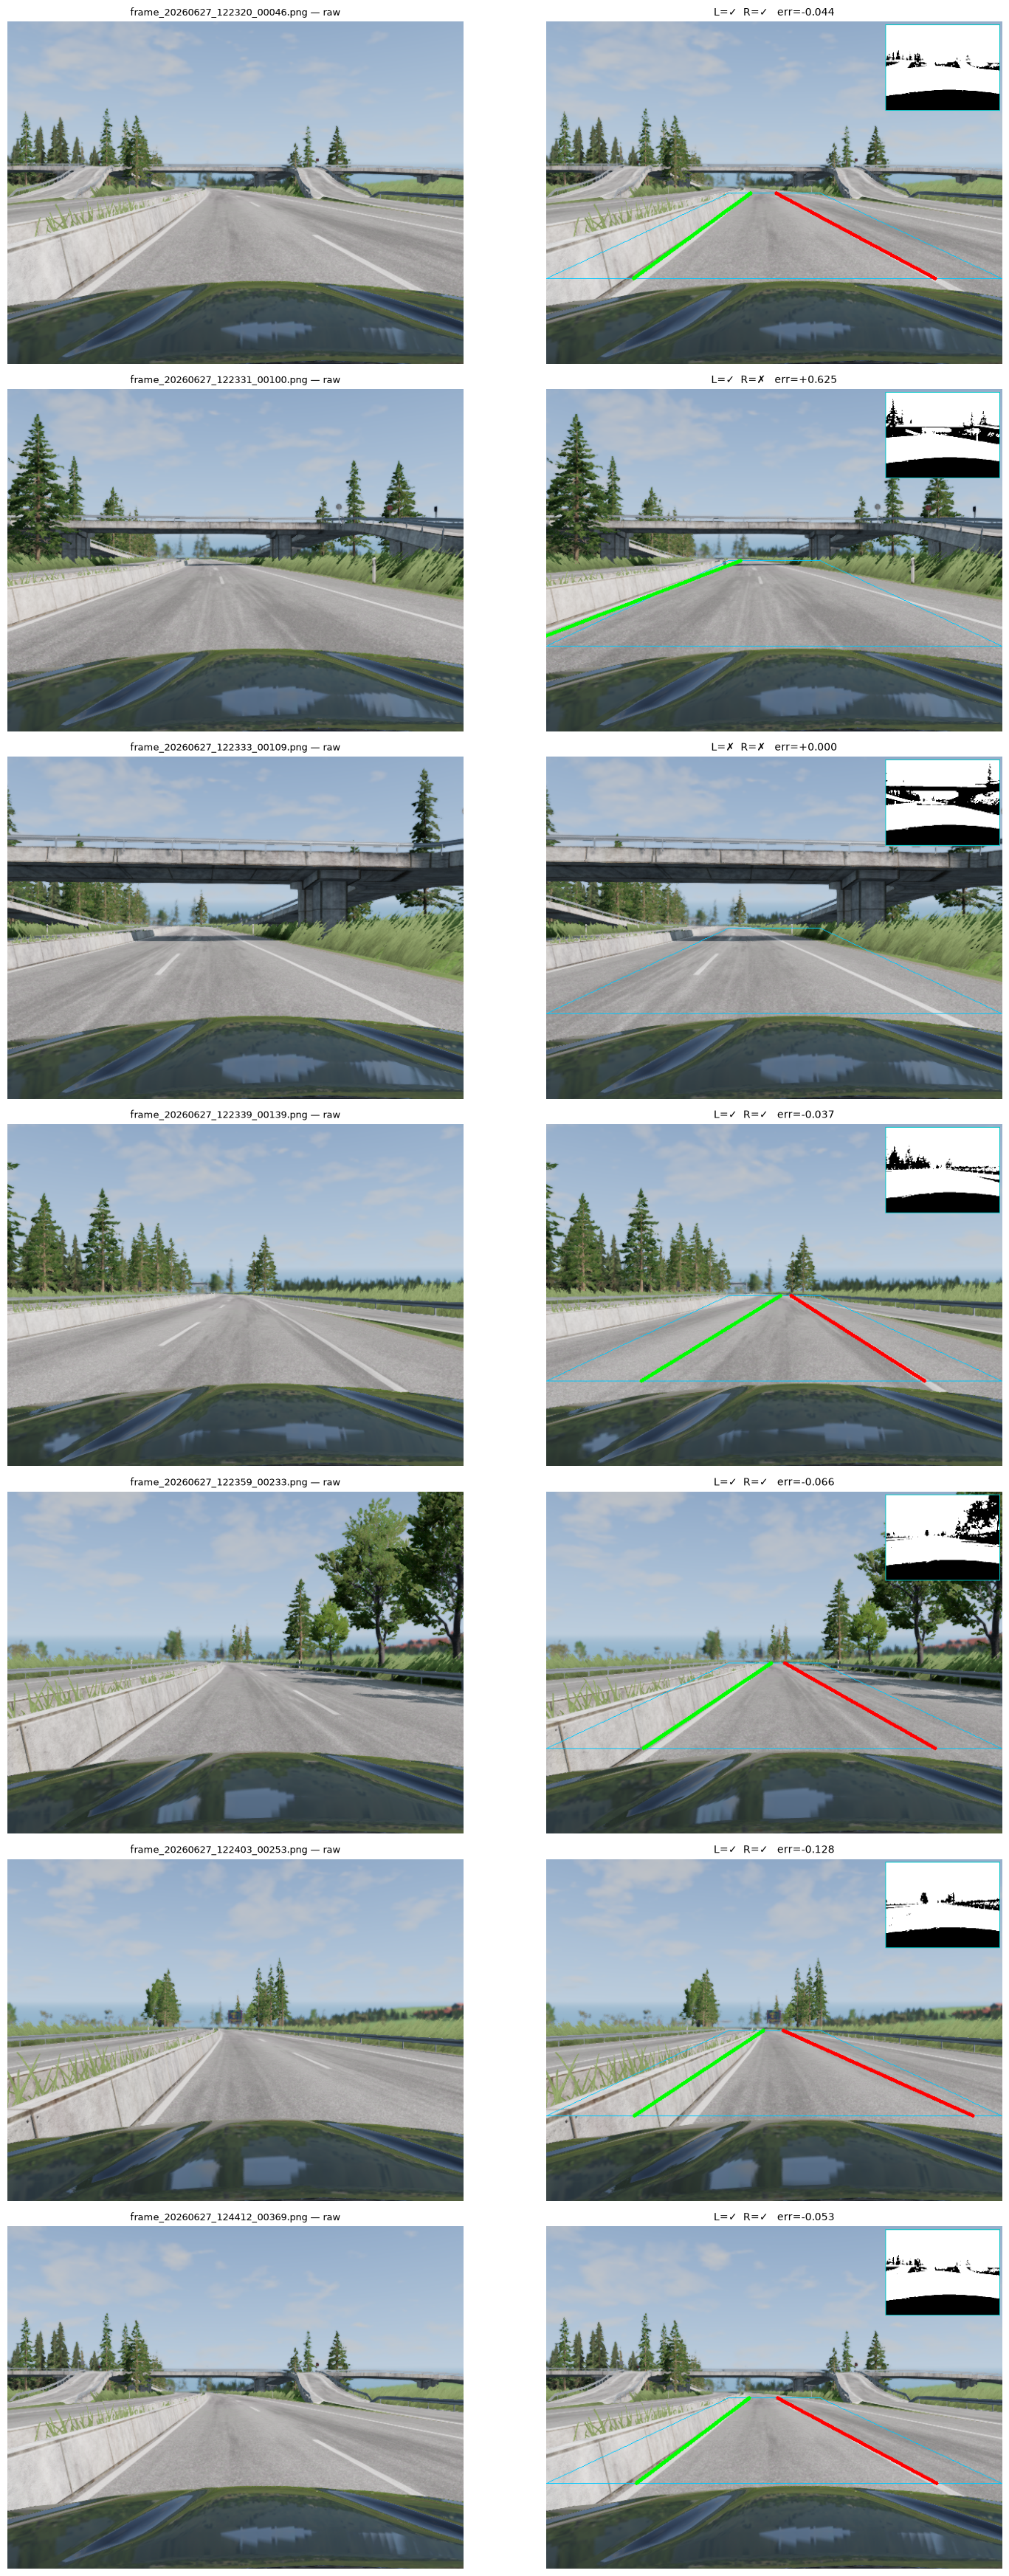

In [2]:
# ── Run on ALL screenshots ────────────────────────────────────────────────
# Edit lane_pid.py, re-run cell-1, then re-run this cell to see the effect.

ncols = 2
nrows = len(images)
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
if nrows == 1:
    axes = [axes]

for i, img_path in enumerate(images):
    img_bgr = cv2.imread(str(img_path))
    left_pts, right_pts, overlay = detect_lane_lines(img_bgr)
    err = lane_center_error(left_pts, right_pts, img_bgr.shape[1])

    # Left: raw frame
    axes[i][0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    axes[i][0].set_title(f"{img_path.name} — raw", fontsize=9)
    axes[i][0].axis("off")

    # Right: detection overlay
    axes[i][1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    l_str = f"L={'✓' if left_pts else '✗'}  R={'✓' if right_pts else '✗'}"
    axes[i][1].set_title(f"{l_str}   err={err:+.3f}", fontsize=10)
    axes[i][1].axis("off")

plt.tight_layout()
plt.show()

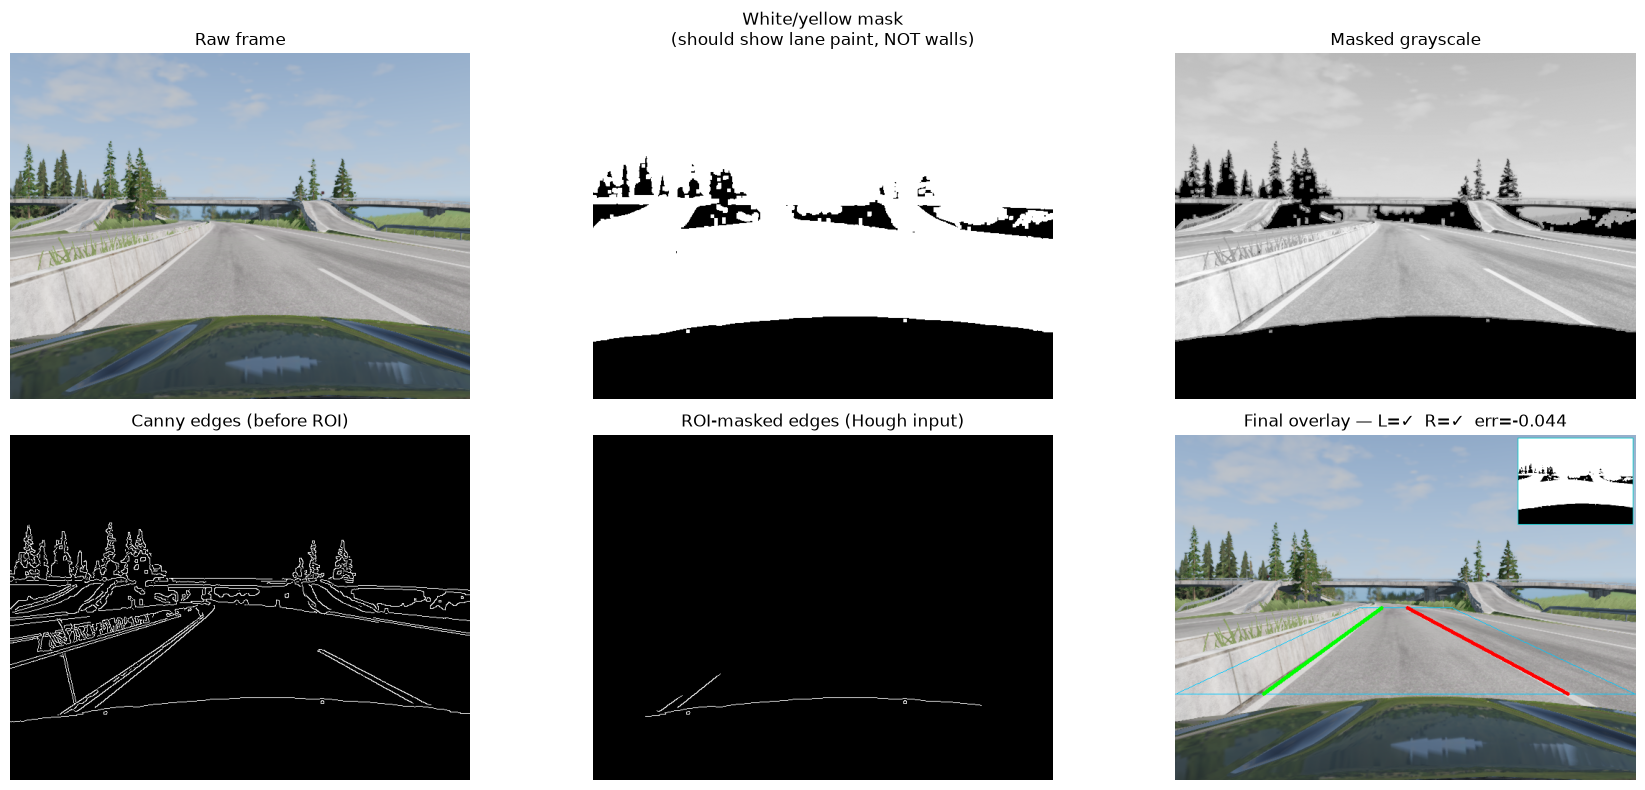

Image size: 640x480
L channel  — min=13  max=230  mean=152.4
S channel  — min=0  max=116  mean=45.0
White mask pixels: 229542 (74.7% of frame)
Canny edge pixels: 11432 before ROI, 661 after ROI


In [5]:
# ── Single-image deep dive ────────────────────────────────────────────────
# Set IDX to whichever image is giving trouble.
IDX = 0

img_bgr = cv2.imread(str(images[IDX]))
h, w = img_bgr.shape[:2]

# Reproduce the internal pipeline steps so you can see where things break
import lane_pid as _lp
importlib.reload(_lp)

hls        = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HLS)
color_mask = _lp._white_yellow_mask(img_bgr)
gray       = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
filtered   = cv2.bitwise_and(gray, gray, mask=color_mask)
blur       = cv2.GaussianBlur(filtered, (5, 5), 0)
edges      = cv2.Canny(blur, 30, 100)
roi        = _lp._roi_mask(edges)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

axes[0][0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
axes[0][0].set_title("Raw frame")

axes[0][1].imshow(color_mask, cmap="gray")
axes[0][1].set_title("White/yellow mask\n(should show lane paint, NOT walls)")

axes[0][2].imshow(filtered, cmap="gray")
axes[0][2].set_title("Masked grayscale")

axes[1][0].imshow(edges, cmap="gray")
axes[1][0].set_title("Canny edges (before ROI)")

axes[1][1].imshow(roi, cmap="gray")
axes[1][1].set_title("ROI-masked edges (Hough input)")

left_pts, right_pts, overlay = _lp.detect_lane_lines(img_bgr)
err = _lp.lane_center_error(left_pts, right_pts, w)
axes[1][2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
l_str = f"L={'✓' if left_pts else '✗'}  R={'✓' if right_pts else '✗'}"
axes[1][2].set_title(f"Final overlay — {l_str}  err={err:+.3f}")

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

# Pixel stats to help tune thresholds
L_channel = hls[:, :, 1]
S_channel = hls[:, :, 2]
print(f"Image size: {w}x{h}")
print(f"L channel  — min={L_channel.min()}  max={L_channel.max()}  mean={L_channel.mean():.1f}")
print(f"S channel  — min={S_channel.min()}  max={S_channel.max()}  mean={S_channel.mean():.1f}")
print(f"White mask pixels: {color_mask.sum() // 255} ({100*color_mask.sum()//255/(h*w):.1f}% of frame)")
print(f"Canny edge pixels: {(edges > 0).sum()} before ROI, {(roi > 0).sum()} after ROI")

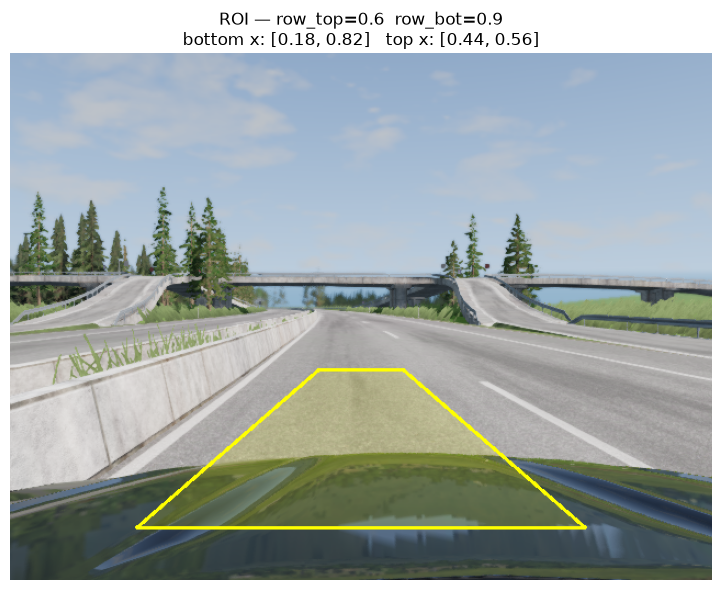

When the trapezoid covers the lane markings and excludes the walls/sky,
copy these values into lane_pid.py _roi_mask() and detect_lane_lines().


In [4]:
# ── ROI visualiser ────────────────────────────────────────────────────────
# Shows the trapezoid drawn on the raw frame so you can judge if it covers
# the lane markings. Tweak row_top / row_bot / corner fractions here first,
# then copy the winning values into lane_pid.py._roi_mask.

IDX     = 0
row_top = 0.60   # ← tune here
row_bot = 0.90   # ← tune here
left_bottom_x  = 0.18  # ← tune here
right_bottom_x = 0.82  # ← tune here
left_top_x     = 0.44  # ← tune here
right_top_x    = 0.56  # ← tune here

img_bgr = cv2.imread(str(images[IDX]))
h, w = img_bgr.shape[:2]
vis = img_bgr.copy()

pts = np.array([[
    [int(w * left_bottom_x),  int(h * row_bot)],
    [int(w * left_top_x),     int(h * row_top)],
    [int(w * right_top_x),    int(h * row_top)],
    [int(w * right_bottom_x), int(h * row_bot)],
]], dtype=np.int32)

cv2.polylines(vis, pts, isClosed=True, color=(0, 255, 255), thickness=2)
# Shade the ROI area
overlay_shade = vis.copy()
cv2.fillPoly(overlay_shade, pts, (0, 255, 255))
vis = cv2.addWeighted(vis, 0.85, overlay_shade, 0.15, 0)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title(
    f"ROI — row_top={row_top}  row_bot={row_bot}\n"
    f"bottom x: [{left_bottom_x}, {right_bottom_x}]   top x: [{left_top_x}, {right_top_x}]"
)
plt.axis("off")
plt.tight_layout()
plt.show()

print("When the trapezoid covers the lane markings and excludes the walls/sky,")
print("copy these values into lane_pid.py _roi_mask() and detect_lane_lines().")